# 단계 4.3 — Feature Mart EDA (탐색적 데이터 분석)

> **목적**: `pv_model_benchmark_execution.md` 섹션 4.3 요구사항 충족  
> - site별 발전 프로파일 (일별 peak 패턴 정상 여부)  
> - 계절별 clear-sky vs 실측 발전량 산점도  
> - 기상 feature 분포 (이상 outlier 없는지)  
> - train/valid/test 경계에서 급격한 분포 변화 없는지

## 0. 라이브러리 및 경로 설정

In [128]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as ticker

# 경로 설정 — 노트북은 project/notebooks/ 에 위치
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTIFACTS    = os.path.join(PROJECT_ROOT, 'artifacts')
SNAPSHOT     = os.path.join(ARTIFACTS, 'dataset_snapshot')
FEATURE_MART = os.path.join(ARTIFACTS, 'feature_mart_per_site')  # per-site split 버전

print('PROJECT_ROOT :', PROJECT_ROOT)
print('FEATURE_MART :', FEATURE_MART)

import matplotlib
import matplotlib.font_manager as _fm

# 한글 지원 폰트 우선순위 탐색 (시스템 환경에 따라 자동 선택)
_KO_FONT_CANDIDATES = [
    'NanumGothic',
    'Noto Sans CJK KR',
    'Noto Sans CJK JP',   # TTC 내 KR 포함
    'AppleGothic',
    'Malgun Gothic',
]
_available = {f.name for f in _fm.fontManager.ttflist}
_ko_font = next((f for f in _KO_FONT_CANDIDATES if f in _available), None)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
if _ko_font:
    matplotlib.rcParams['font.family'] = _ko_font
matplotlib.rcParams['axes.unicode_minus'] = False

print(f'사용 폰트: {matplotlib.rcParams["font.family"]}')

PROJECT_ROOT : /disk1/krems/time_forecasting/project
FEATURE_MART : /disk1/krems/time_forecasting/project/artifacts/feature_mart_per_site
사용 폰트: ['Noto Sans CJK JP']


## 1. 데이터 로드

In [129]:
# --- split manifest (global 기준, 참조용) ---
import yaml
with open(os.path.join(ARTIFACTS, 'split_manifest.yaml')) as f:
    manifest = yaml.safe_load(f)

TRAIN_END  = pd.Timestamp(manifest['split']['train_end'])
VALID_END  = pd.Timestamp(manifest['split']['valid_end'])
TEST_END   = pd.Timestamp(manifest['split']['test_end'])
DATA_START = pd.Timestamp(manifest['data']['data_start'])

print(f'Global Train : {DATA_START}  ~  {TRAIN_END}')
print(f'Global Valid : {TRAIN_END}   ~  {VALID_END}')
print(f'Global Test  : {VALID_END}   ~  {TEST_END}')

# --- per-site split manifest (실제 split 경계) ---
with open(os.path.join(ARTIFACTS, 'per_site_split_manifest.json')) as f:
    per_site_manifest = json.load(f)

SITE_BOUNDS = {int(k): v for k, v in per_site_manifest['sites'].items()}
print(f'\nPer-site split: {len(SITE_BOUNDS)} sites  비율={per_site_manifest["split_ratios"]}')

Global Train : 2022-01-01 00:00:00  ~  2024-12-31 23:00:00
Global Valid : 2024-12-31 23:00:00   ~  2025-09-30 23:00:00
Global Test  : 2025-09-30 23:00:00   ~  2026-04-23 23:00:00

Per-site split: 100 sites  비율=[0.7, 0.15, 0.15]


In [130]:
# --- plant metadata ---
df_meta = pd.read_parquet(os.path.join(SNAPSHOT, 'plant_meta.parquet'))
df_meta = df_meta.drop_duplicates('cid_seq').set_index('cid_seq')
print(f'site 수: {len(df_meta)}')
df_meta[['plant_nm', 'latitude', 'longitude', 'azimuth', 'angle']].head()

site 수: 4919


,plant_nm,latitude,longitude,azimuth,angle
cid_seq,,,,,
1,(주)프레시코,36.142175,127.138305,25,180
2,한국건설연구소 주식회사,36.576984,127.513043,25,180
3,한국건설연구소 주식회사,36.576984,127.513043,25,180
4,한국건설연구소 주식회사,36.576984,127.513043,25,180
5,한국건설연구소 주식회사,36.576984,127.513043,25,180


In [131]:
# --- feature mart 전체 로드 (train + valid + test) ---
def load_split(split: str) -> pd.DataFrame:
    """한 split의 모든 site parquet을 읽어 cid_seq 컬럼을 추가한 뒤 반환."""
    split_dir = os.path.join(FEATURE_MART, split)
    frames = []
    for fname in sorted(os.listdir(split_dir)):
        if not fname.endswith('.parquet'):
            continue
        cid = int(fname.replace('.parquet', ''))
        df = pd.read_parquet(os.path.join(split_dir, fname))
        df['cid_seq'] = cid
        frames.append(df)
    return pd.concat(frames).sort_index()

print('train 로드 중...')
df_train = load_split('train')
print('valid 로드 중...')
df_valid = load_split('valid')
print('test  로드 중...')
df_test  = load_split('test')

print(f'\ntrain: {df_train.shape}  ({df_train["cid_seq"].nunique()} sites)')
print(f'valid: {df_valid.shape}  ({df_valid["cid_seq"].nunique()} sites)')
print(f'test : {df_test.shape}   ({df_test["cid_seq"].nunique()} sites)')

# ── per-site split 전체 분석용 통합 DataFrame ──────────────────────────────
# per-site split에서 각 site의 2025 데이터는 train/valid/test에 혼재될 수 있음.
# 기간·분포 분석 시 df_all 을 기준으로 사용하고, year 필터로 2025 데이터를 추출한다.
df_all = pd.concat([
    df_train.assign(split='train'),
    df_valid.assign(split='valid'),
    df_test.assign(split='test'),
]).sort_index()

print(f'all  : {df_all.shape}   ({df_all["cid_seq"].nunique()} sites, {df_all.index.min().date()}~{df_all.index.max().date()})')
print(f'  2025년 포함 행: {(df_all.index.year == 2025).sum():,}')

train 로드 중...
valid 로드 중...
test  로드 중...

train: (850620, 33)  (100 sites)
valid: (182293, 33)  (100 sites)
test : (182327, 33)   (100 sites)
all  : (1215240, 34)   (100 sites, 2023-11-10~2026-04-23)
  2025년 포함 행: 787,320


In [132]:
# --- quality report ---
with open(os.path.join(FEATURE_MART, 'quality_report.json')) as f:
    qr = json.load(f)
print(json.dumps(qr, indent=2, ensure_ascii=False))

{
  "checked_at": "2026-04-24T17:48:35.584488",
  "split_mode": "per_site",
  "note": "PV 인버터는 야간에 꺼져 데이터를 미전송(NaN)함. 전체 결측률이 높은 것은 정상이며 daytime 결측률로 품질 판단.",
  "splits": {
    "train": {
      "n_sites": 100,
      "total_rows": 851065,
      "avg_hours_per_site": 8510.65,
      "missing_rate_total": 0.2772,
      "missing_rate_daytime": 0.0258,
      "daytime_zero_ratio": 0.0894,
      "pass": true
    },
    "valid": {
      "n_sites": 100,
      "total_rows": 182378,
      "avg_hours_per_site": 1823.78,
      "missing_rate_total": 0.2931,
      "missing_rate_daytime": 0.0314,
      "daytime_zero_ratio": 0.104,
      "pass": true
    },
    "test": {
      "n_sites": 100,
      "total_rows": 182436,
      "avg_hours_per_site": 1824.36,
      "missing_rate_total": 0.2969,
      "missing_rate_daytime": 0.0103,
      "daytime_zero_ratio": 0.0798,
      "pass": true
    }
  },
  "issues": [],
  "warnings": [],
  "overall_pass": true
}


In [133]:
# 컬럼 목록 확인
print('Feature 컬럼 목록:')
for i, c in enumerate(df_train.columns):
    print(f'  {i:2d}. {c}')

Feature 컬럼 목록:
   0. normalized_power
   1. ta
   2. rn
   3. ws
   4. wd
   5. hm
   6. pa
   7. si
   8. ss
   9. dc10Tca
  10. solar_elevation
  11. solar_azimuth
  12. clearsky_ghi
  13. pv_roll_mean_24h
  14. pv_roll_mean_72h
  15. pv_roll_mean_168h
  16. pv_roll_std_24h
  17. pv_roll_std_72h
  18. pv_roll_std_168h
  19. pv_lag_24h
  20. pv_lag_168h
  21. hour
  22. dayofweek
  23. month
  24. dayofyear
  25. is_holiday
  26. t2m_c
  27. reh
  28. wsd
  29. vec
  30. tp_mm
  31. tcc
  32. cid_seq


---
## 2. Site별 발전 프로파일 (일별 peak 패턴)
> 검증 목표: 인버터 야간 차단, 일출/일몰 패턴, 계절성이 정상적으로 나타나는지 확인

In [134]:
# 대표 site 선정 — 2025년 실제 발전 품질 기준 (낮 시간대 양의 발전 시간 多)
# per-site split에서 2025 데이터는 train/valid/test에 혼재 → df_all 기준
df_2025      = df_all[df_all.index.year == 2025]
df_2025_day  = df_2025[df_2025['solar_elevation'] > 5]   # 낮 시간대만

# 낮 평균 발전량 (정상 발전 여부 판단)
site_day_mean = df_2025_day.groupby('cid_seq')['normalized_power'].mean()

# 낮 시간대 실제 발전 시간 (normalized_power > 0.01 인 시간)
site_pos_hours = (
    df_2025_day.groupby('cid_seq')['normalized_power']
    .apply(lambda s: (s > 0.01).sum())
)

# 품질 필터: 낮 평균 > 0.15 (발전이 제대로 되는 site만)
quality_sites = site_day_mean[site_day_mean > 0.15].index
site_pos_filtered = site_pos_hours[site_pos_hours.index.isin(quality_sites)]
TOP5_SITES = site_pos_filtered.sort_values(ascending=False).head(5).index.tolist()

print('2025년 품질 기준 대표 5개 site (낮 평균>0.15, positive 시간 多):')
print(f'{"cid":>6}  {"positive_h":>10}  {"daytime_mean":>12}  {"capacity":>10}  active 기간')
for s in TOP5_SITES:
    cap    = df_meta.loc[s, 'ivt_capacity_kw'] if s in df_meta.index else 'N/A'
    bounds = SITE_BOUNDS.get(s, {})
    print(f'  {s:4d}  {site_pos_filtered.get(s,0):>10,}h  {site_day_mean.get(s,0):>12.4f}  {str(cap):>10} kW'
          f'  {bounds.get("active_start","?")[:10]}~{bounds.get("active_end","?")[:10]}')

# 제외된 저품질 site 안내
excluded = set(
    df_2025['cid_seq'].unique().tolist()
) - set(quality_sites.tolist())
print(f'\n낮 평균 < 0.15 제외 site: {len(excluded)}개 (데이터 이상 또는 설비 미동작 의심)')

2025년 품질 기준 대표 5개 site (낮 평균>0.15, positive 시간 多):
   cid  positive_h  daytime_mean    capacity  active 기간
   596       4,043h        0.8467         3.5 kW  2024-03-12~2026-04-23
     7       3,994h        0.3438        50.0 kW  2024-03-14~2026-04-23
     8       3,989h        0.3407        50.0 kW  2023-12-07~2026-04-23
  2162       3,977h        0.3441        34.0 kW  2024-12-02~2026-04-23
    11       3,970h        0.2696        50.0 kW  2024-03-14~2026-04-23

낮 평균 < 0.15 제외 site: 1개 (데이터 이상 또는 설비 미동작 의심)


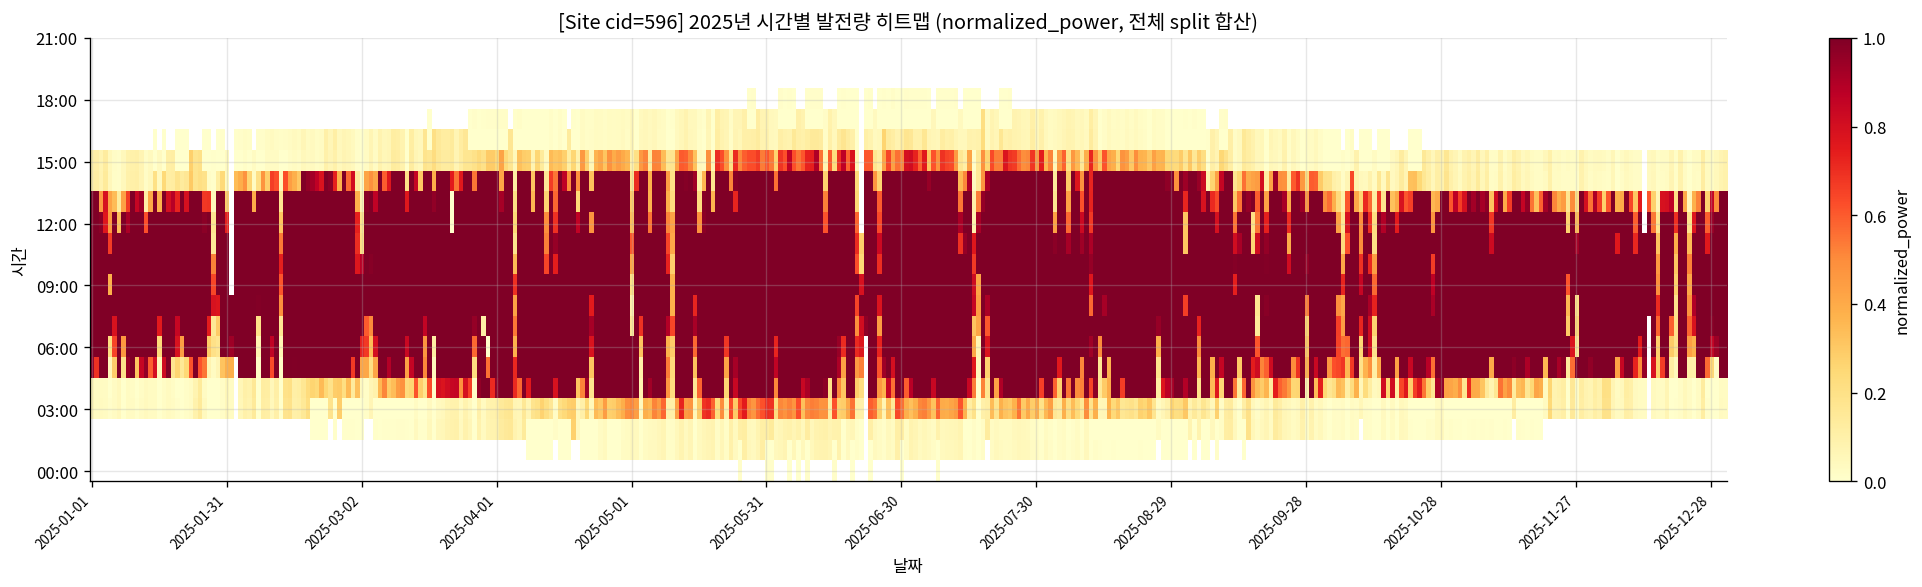

In [135]:
# 2-1. 대표 site 1개 — 1년간 시계열 히트맵 (시간 × 날짜)
# per-site split: 2025 데이터가 어느 split에 있든 df_all에서 추출
cid = TOP5_SITES[0]
site_df = df_all[(df_all['cid_seq'] == cid) & (df_all.index.year == 2025)].copy()

pivot = (
    site_df.assign(
        date=site_df.index.date,
        hour=site_df.index.hour
    ).pivot_table(index='hour', columns='date', values='normalized_power', aggfunc='mean')
)

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(
    pivot.values,
    aspect='auto',
    origin='lower',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    interpolation='nearest'
)
plt.colorbar(im, ax=ax, label='normalized_power')
ax.set_yticks(range(0, 24, 3))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])
ax.set_ylabel('시간')

ncols = pivot.shape[1]
xtick_step = max(1, ncols // 12)
xtick_pos  = list(range(0, ncols, xtick_step))
xtick_lab  = [str(pivot.columns[i]) for i in xtick_pos]
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_lab, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('날짜')
ax.set_title(f'[Site cid={cid}] 2025년 시간별 발전량 히트맵 (normalized_power, 전체 split 합산)')
plt.tight_layout()
plt.show()

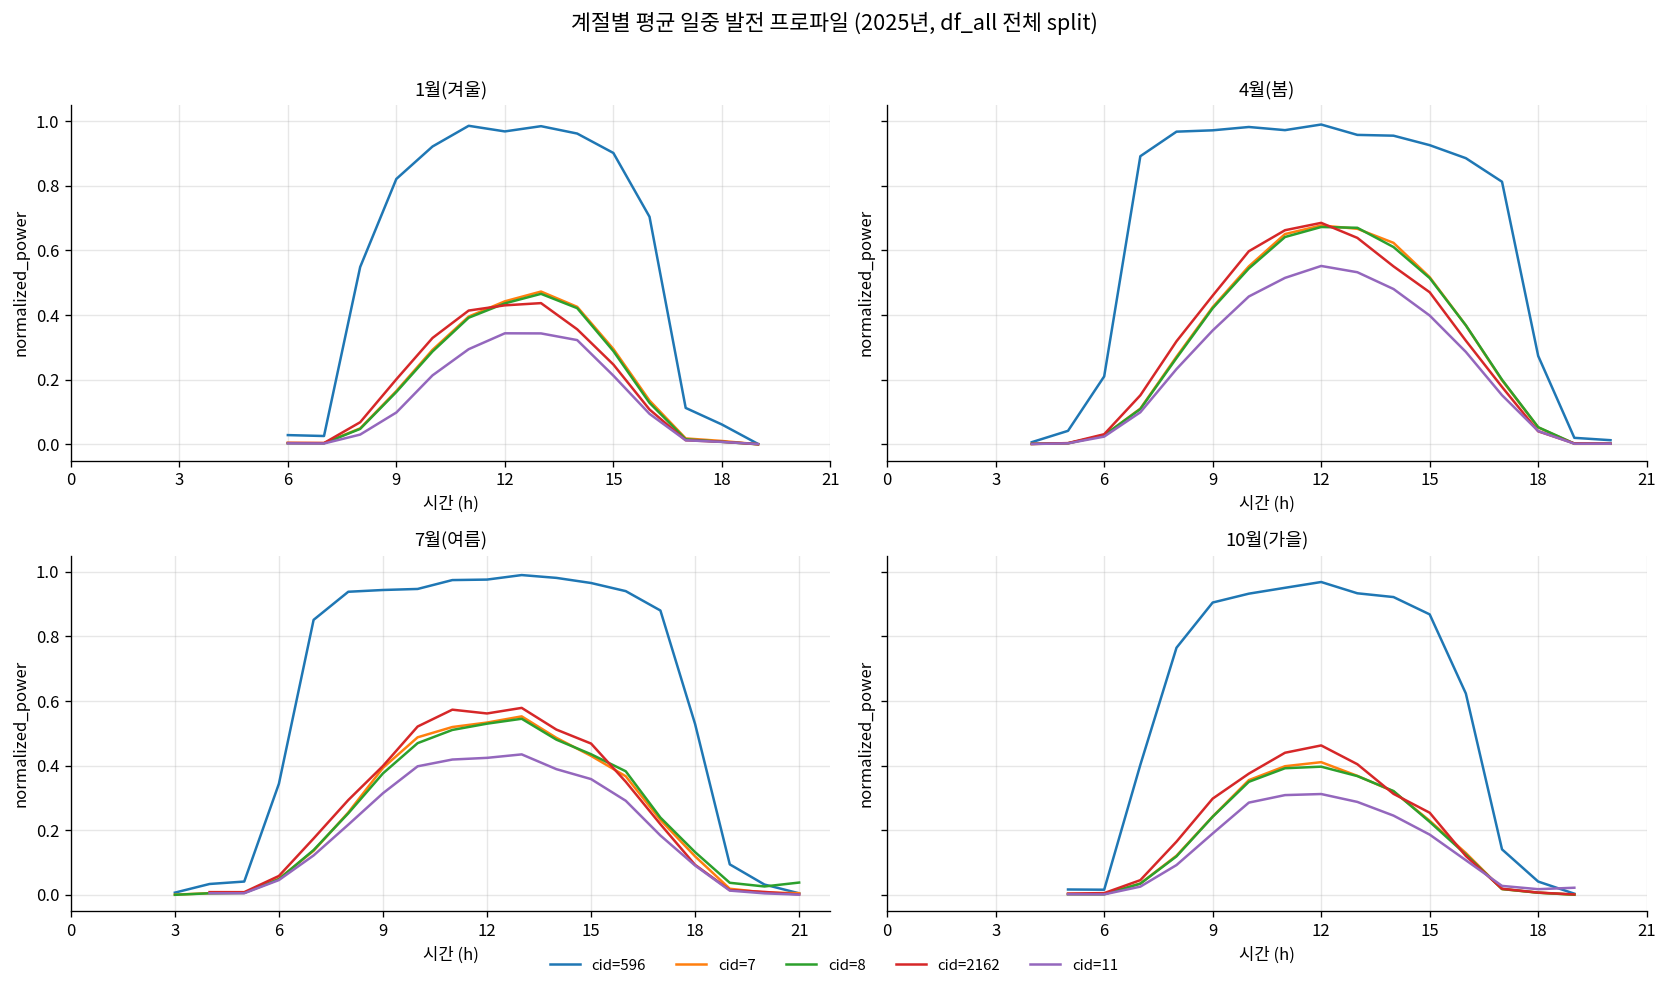

In [136]:
# 2-2. 5개 site 월별 평균 일중 발전 프로파일 (2025년 기준)
# per-site split: 월별로 어느 split에 속하든 df_all에서 추출
MONTHS_CONFIG = {
    1:  '1월(겨울)',
    4:  '4월(봄)',
    7:  '7월(여름)',
    10: '10월(가을)',
}
COLORS = plt.cm.tab10.colors
PLOT_SITES = TOP5_SITES[:]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax_idx, (month, label) in enumerate(MONTHS_CONFIG.items()):
    ax = axes[ax_idx]
    has_data = False
    for i, cid in enumerate(PLOT_SITES):
        s = df_all[
            (df_all['cid_seq'] == cid) &
            (df_all.index.year == 2025) &
            (df_all.index.month == month)
        ]
        if len(s) == 0:
            continue
        profile = s.groupby(s.index.hour)['normalized_power'].mean()
        ax.plot(profile.index, profile.values,
                label=f'cid={cid}', color=COLORS[i], linewidth=1.5)
        has_data = True
    ax.set_title(label + ('' if has_data else ' (데이터 없음)'), fontsize=11)
    ax.set_xlabel('시간 (h)')
    ax.set_ylabel('normalized_power')
    ax.set_xticks(range(0, 24, 3))
    ax.set_ylim(-0.05, 1.05)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=5, fontsize=9, frameon=False)
fig.suptitle('계절별 평균 일중 발전 프로파일 (2025년, df_all 전체 split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

cid=8  데이터 행 수: 168, 발전량 유효행: 127
포함 split: ['train']


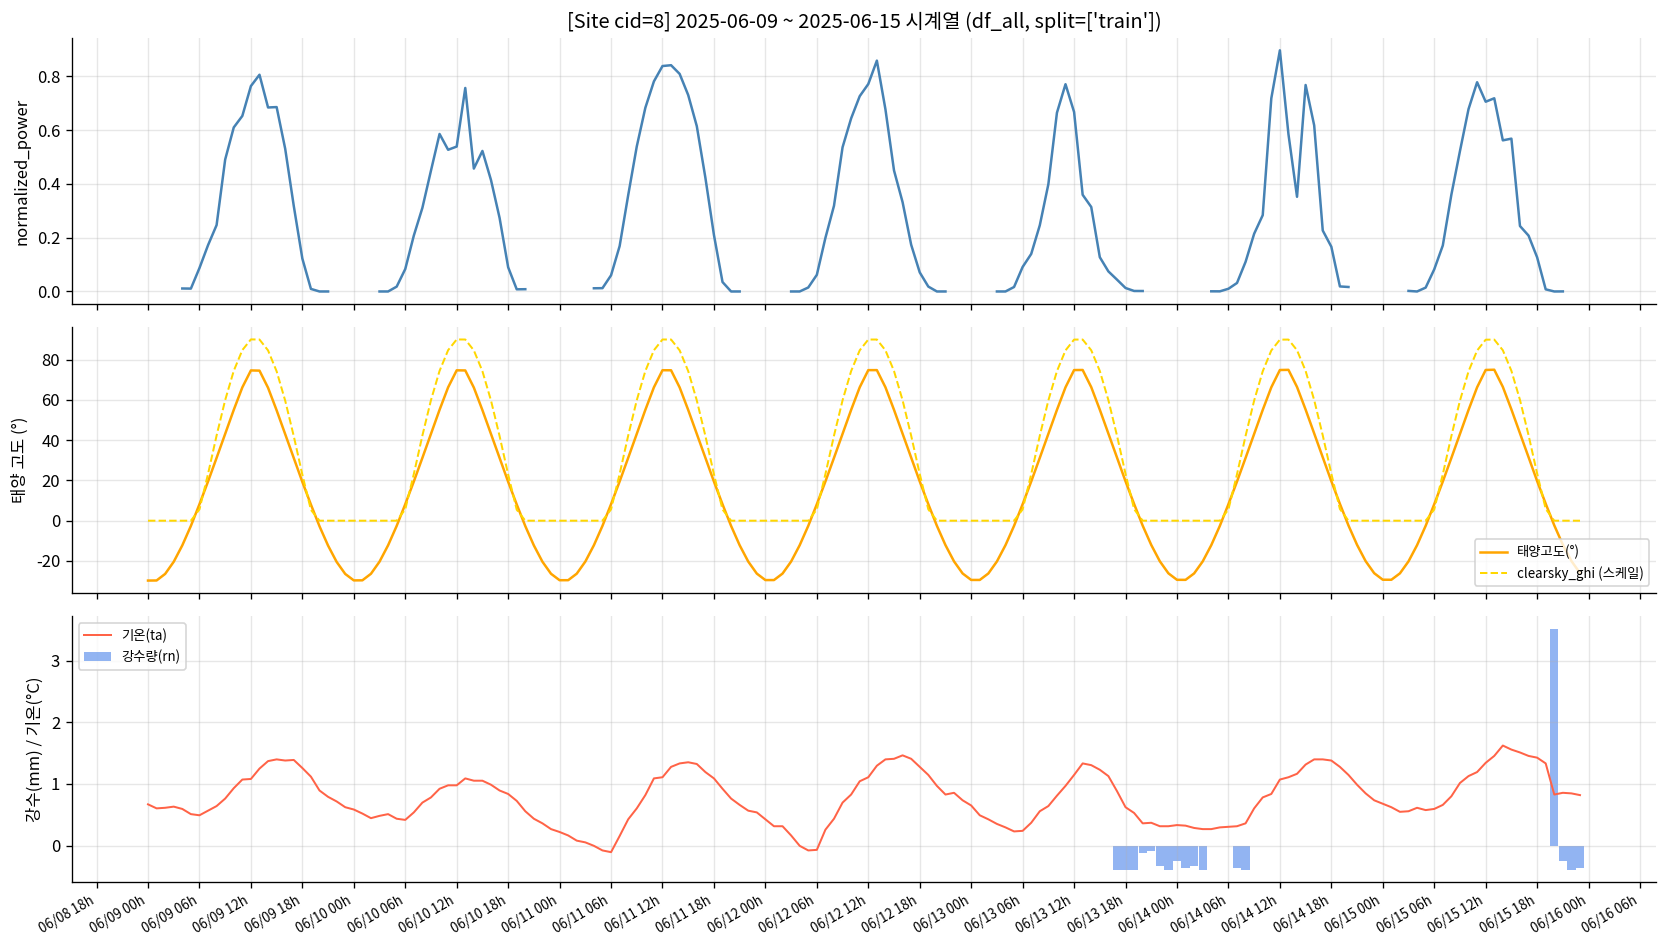

In [137]:
# 2-3. 대표 site — 7일 연속 시계열 (2025년 6월)
# per-site split: df_all에서 해당 site의 2025-06 구간 추출 (split 무관)
cid = TOP5_SITES[2]
week_df = df_all[
    (df_all['cid_seq'] == cid) &
    (df_all.index >= '2025-06-09') &
    (df_all.index <  '2025-06-16')
].copy()

# 데이터 없으면 가장 가까운 6월로 fallback
if len(week_df) == 0 or week_df['normalized_power'].notna().sum() == 0:
    cid = TOP5_SITES[0]
    week_df = df_all[
        (df_all['cid_seq'] == cid) &
        (df_all.index >= '2025-06-09') &
        (df_all.index <  '2025-06-16')
    ].copy()

print(f'cid={cid}  데이터 행 수: {len(week_df)}, 발전량 유효행: {week_df["normalized_power"].notna().sum()}')
split_info = week_df["split"].unique().tolist() if "split" in week_df.columns else []
print(f'포함 split: {split_info}')

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(week_df.index, week_df['normalized_power'], color='steelblue', linewidth=1.5)
axes[0].set_ylabel('normalized_power')
axes[0].set_title(f'[Site cid={cid}] 2025-06-09 ~ 2025-06-15 시계열 (df_all, split={split_info})')

cghi_max = week_df['clearsky_ghi'].max()
axes[1].plot(week_df.index, week_df['solar_elevation'], color='orange', linewidth=1.5, label='태양고도(°)')
axes[1].plot(week_df.index,
             week_df['clearsky_ghi'] / (cghi_max if cghi_max > 0 else 1) * 90,
             color='gold', linewidth=1.2, linestyle='--', label='clearsky_ghi (스케일)')
axes[1].set_ylabel('태양 고도 (°)')
axes[1].legend(fontsize=8)

axes[2].bar(week_df.index, week_df['rn'].fillna(0), width=0.04, color='cornflowerblue', alpha=0.7, label='강수량(rn)')
axes[2].plot(week_df.index, week_df['ta'], color='tomato', linewidth=1.2, label='기온(ta)')
axes[2].set_ylabel('강수(mm) / 기온(°C)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %Hh'))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. 계절별 Clear-sky vs 실측 발전량 산점도
> 검증 목표: clearsky_ghi가 높을수록 발전량이 높아야 함. 맑은 날/흐린 날 분포 확인.

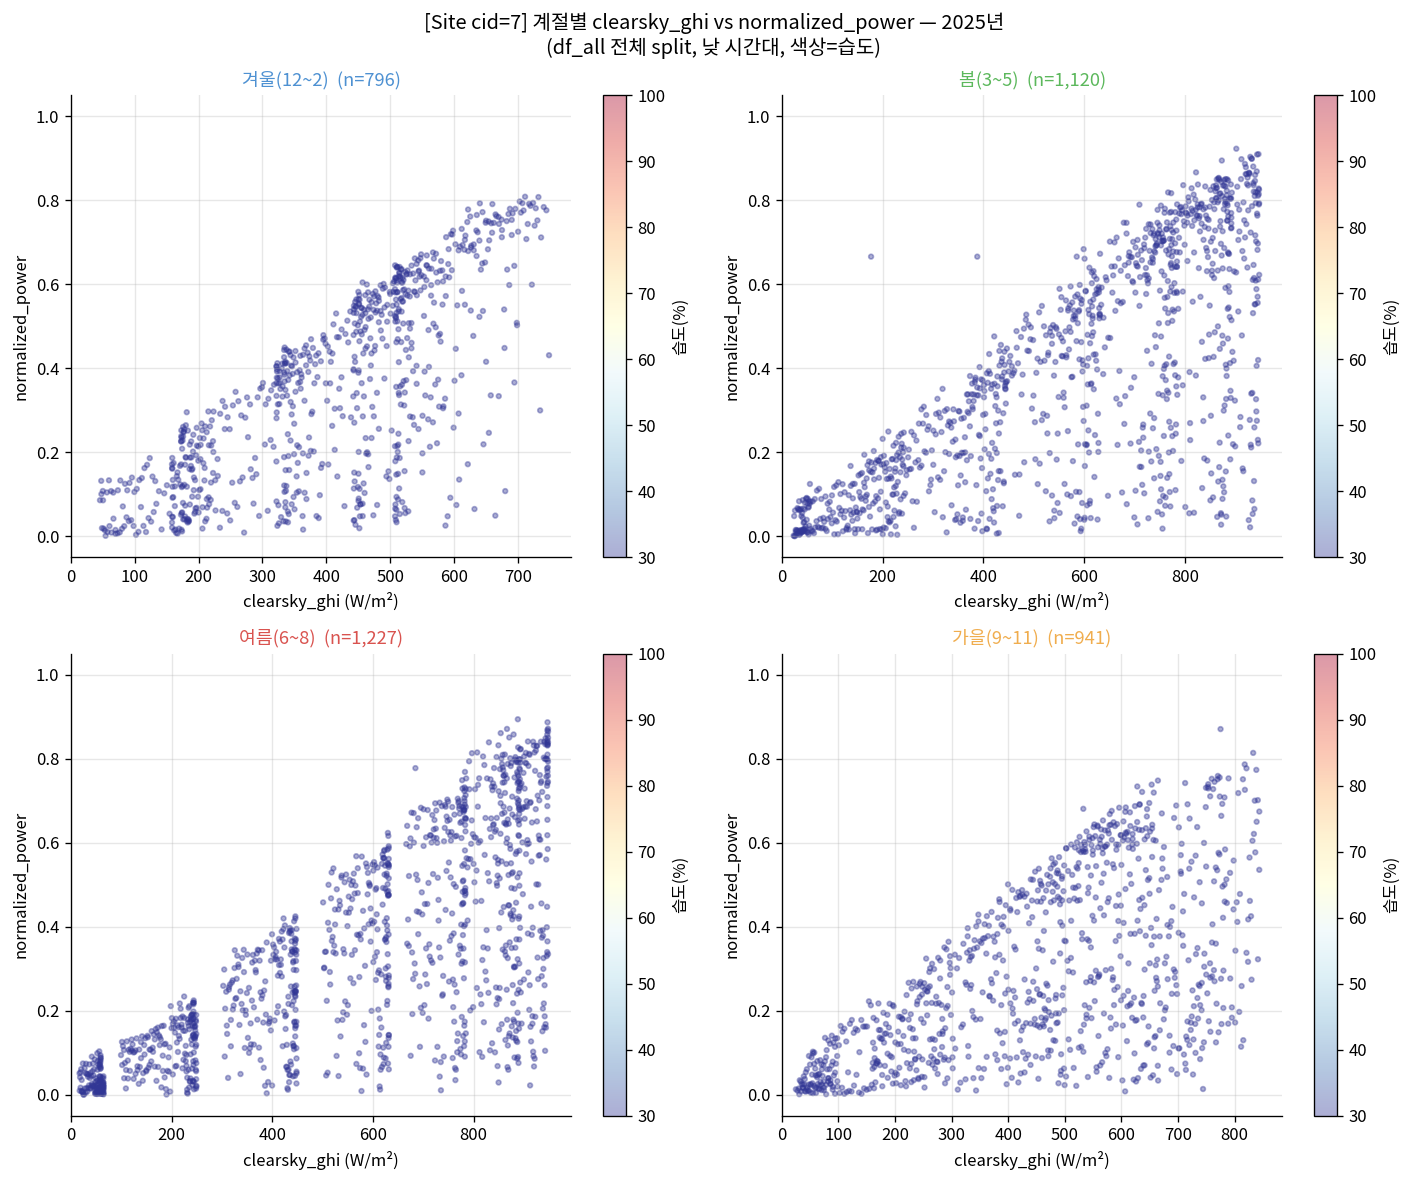

In [151]:
SEASON_MAP = {12:0, 1:0, 2:0,   # 겨울
              3:1,  4:1, 5:1,   # 봄
              6:2,  7:2, 8:2,   # 여름
              9:3,  10:3, 11:3} # 가을
SEASON_NAMES  = ['겨울(12~2)', '봄(3~5)', '여름(6~8)', '가을(9~11)']
SEASON_COLORS = ['#4e91d2', '#5cb85c', '#d9534f', '#f0ad4e']

# 2025년 데이터: df_all에서 해당 site의 2025년 낮 시간 데이터 추출 (split 무관)
cid = TOP5_SITES[1]
sdf_2025 = df_all[
    (df_all['cid_seq'] == cid) &
    (df_all.index.year == 2025) &
    (df_all['solar_elevation'] > 5)
].copy()
sdf_2025['season'] = sdf_2025.index.month.map(SEASON_MAP)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for s_idx in range(4):
    ax   = axes[s_idx]
    data = sdf_2025[sdf_2025['season'] == s_idx]
    if len(data) == 0:
        ax.set_title(f'{SEASON_NAMES[s_idx]}  (데이터 없음)', color=SEASON_COLORS[s_idx], fontsize=11)
        continue
    sample = data.sample(min(3000, len(data)), random_state=42)

    sc = ax.scatter(
        sample['clearsky_ghi'],
        sample['normalized_power'],
        c=sample['hm'],
        cmap='RdYlBu_r',
        alpha=0.4, s=8, vmin=30, vmax=100
    )
    plt.colorbar(sc, ax=ax, label='습도(%)')
    ax.set_xlabel('clearsky_ghi (W/m²)')
    ax.set_ylabel('normalized_power')
    ax.set_xlim(0, None)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{SEASON_NAMES[s_idx]}  (n={len(sample):,})', color=SEASON_COLORS[s_idx], fontsize=11)

fig.suptitle(f'[Site cid={cid}] 계절별 clearsky_ghi vs normalized_power — 2025년\n(df_all 전체 split, 낮 시간대, 색상=습도)',
             fontsize=12)
plt.tight_layout()
plt.show()

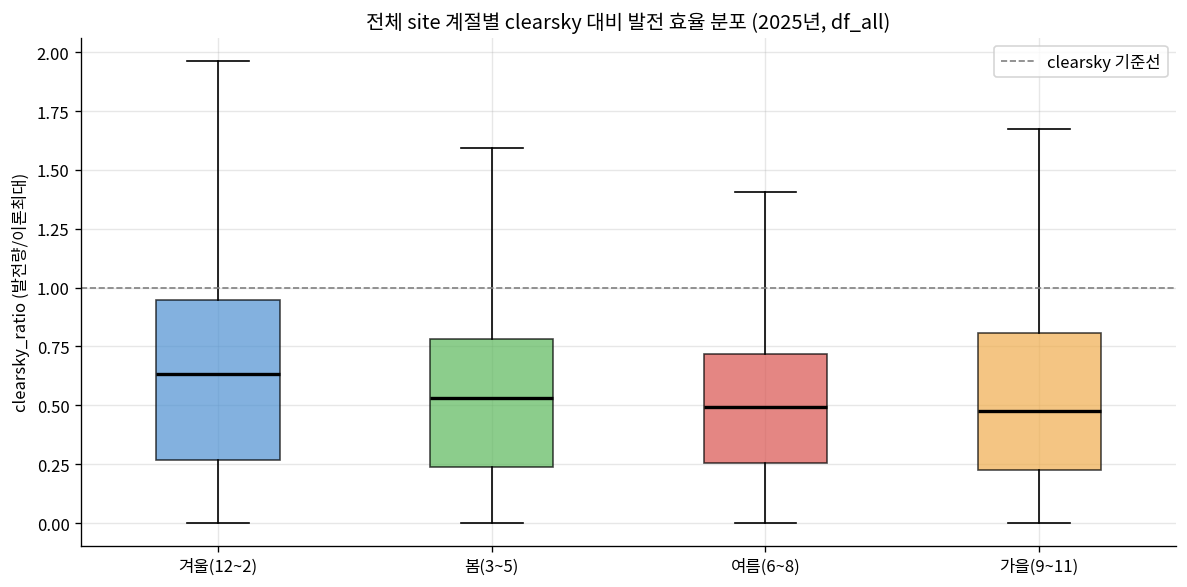

겨울(12~2)         median=0.635  mean=0.658  n=59,274
봄(3~5)           median=0.533  mean=0.542  n=92,315
여름(6~8)          median=0.492  mean=0.518  n=110,982
가을(9~11)         median=0.477  mean=0.559  n=87,608


In [139]:
# 3-2. 전체 site 계절별 clearsky 대비 발전 효율 (clear-sky ratio) — 2025년 (df_all 전체 split)
daytime_all = df_all[
    (df_all['solar_elevation'] > 5) &
    (df_all.index.year == 2025)
].copy()
daytime_all['season'] = daytime_all.index.month.map(SEASON_MAP)

# clearsky_ratio = normalized_power / (clearsky_ghi / clearsky_ghi.max)
# clearsky_ghi가 0인 경우 제외
daytime_all = daytime_all[daytime_all['clearsky_ghi'] > 50]
daytime_all['clearsky_ratio'] = (
    daytime_all['normalized_power'] /
    (daytime_all['clearsky_ghi'] / daytime_all['clearsky_ghi'].max())
).clip(0, 2)

fig, ax = plt.subplots(figsize=(10, 5))
season_data = [daytime_all[daytime_all['season'] == s]['clearsky_ratio'].dropna() for s in range(4)]
bplot = ax.boxplot(
    season_data,
    labels=SEASON_NAMES,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    showfliers=False
)
for patch, color in zip(bplot['boxes'], SEASON_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='clearsky 기준선')
ax.set_ylabel('clearsky_ratio (발전량/이론최대)')
ax.set_title('전체 site 계절별 clearsky 대비 발전 효율 분포 (2025년, df_all)')
ax.legend()
plt.tight_layout()
plt.show()

for s_idx, name in enumerate(SEASON_NAMES):
    d = season_data[s_idx]
    print(f'{name:15s}  median={d.median():.3f}  mean={d.mean():.3f}  n={len(d):,}')

---
## 4. 기상 Feature 분포 (이상 Outlier 확인)
> 검증 목표: z-score 정규화 후에도 극단값 없이 정상 분포를 보이는지 확인

In [140]:
# scaler_stats 로드
with open(os.path.join(FEATURE_MART, 'scaler_stats.json')) as f:
    scaler_stats_raw = json.load(f)

# 구조: {version, fit_end, features: {col: {mean, std}}}
scaler_stats = scaler_stats_raw.get('features', scaler_stats_raw)

print(f'정규화된 feature 수: {len(scaler_stats)}')
print(f'fit 기준 시점: {scaler_stats_raw.get("fit_end", "N/A")}')
print(f'\n{"feature":25s}  {"mean_orig":>10s}  {"std_orig":>10s}')
print('-' * 52)
for col, stat in list(scaler_stats.items())[:20]:
    print(f'  {col:23s}  mean={stat["mean"]:8.3f}  std={stat["std"]:8.3f}')

정규화된 feature 수: 23
fit 기준 시점: 2024-12-31 23:00:00

feature                     mean_orig    std_orig
----------------------------------------------------
  ta                       mean=  15.540  std=  10.691
  rn                       mean=   1.446  std=   3.705
  ws                       mean=   1.804  std=   1.374
  wd                       mean= 172.733  std= 110.919
  hm                       mean=  70.243  std=  20.226
  pa                       mean=1006.879  std=   9.555
  si                       mean= 321.280  std= 281.119
  ss                       mean=   0.467  std=   0.440
  dc10Tca                  mean=   4.929  std=   4.015
  pv_roll_mean_24h         mean=   7.858  std=   4.697
  pv_roll_mean_72h         mean=   6.834  std=   3.336
  pv_roll_mean_168h        mean=   6.823  std=   2.876
  pv_roll_std_24h          mean=   9.354  std=   4.669
  pv_roll_std_72h          mean=   9.338  std=   3.700
  pv_roll_std_168h         mean=   9.632  std=   3.251
  pv_lag_24h         

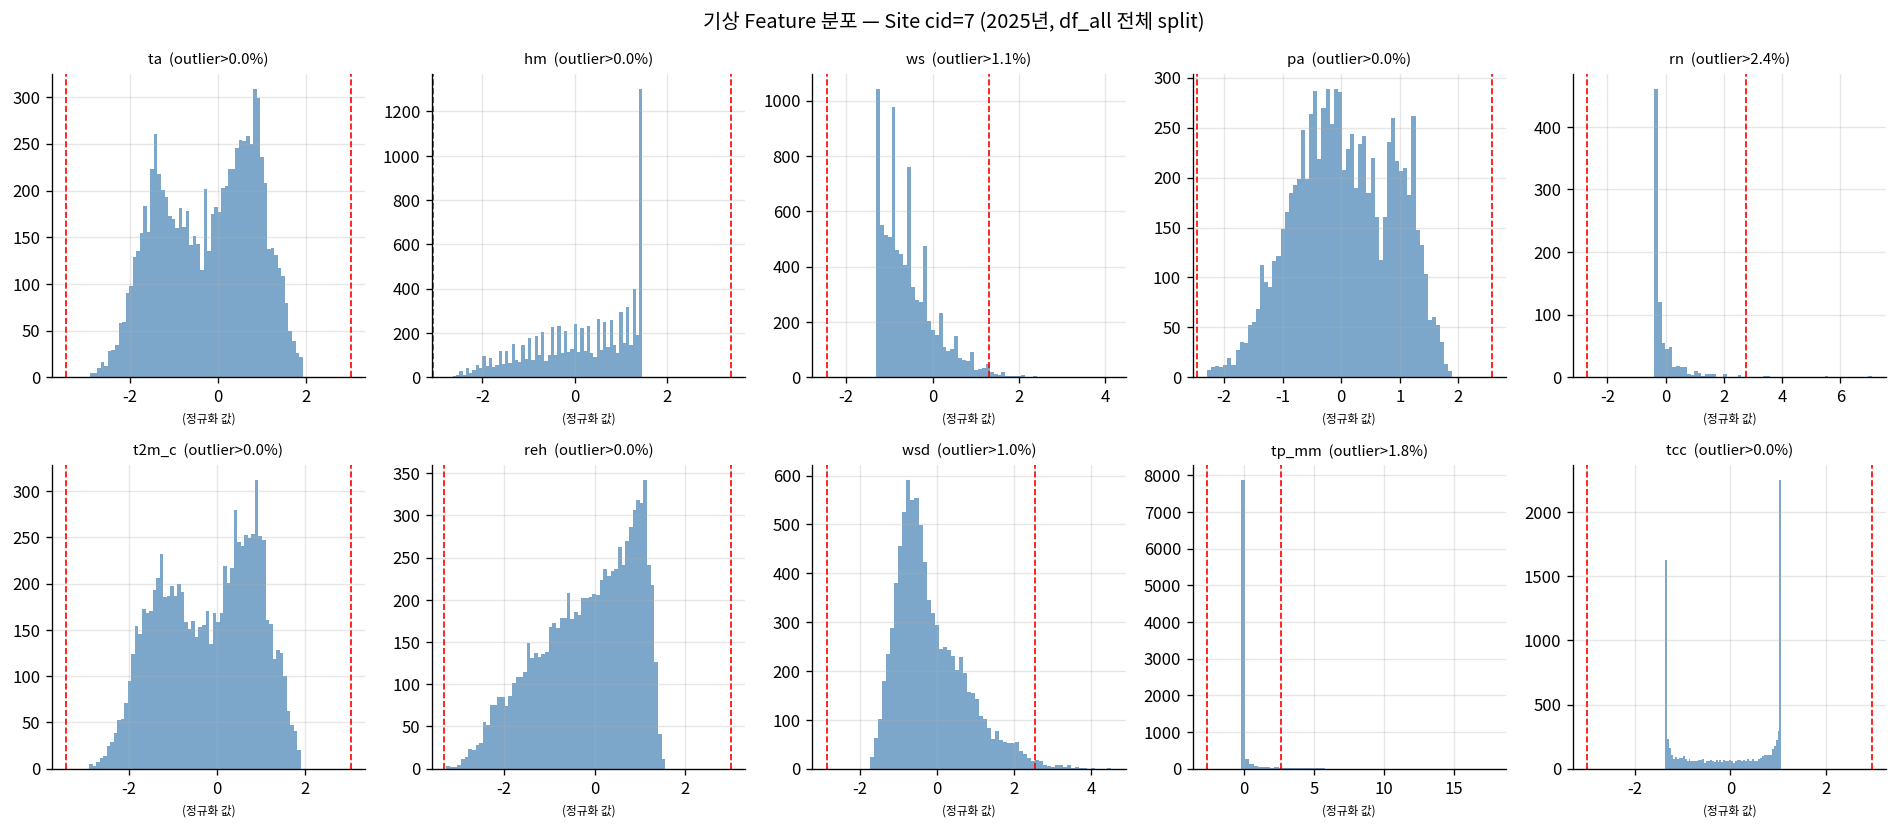

In [141]:
# 4-1. 기상 feature 히스토그램 — 2025년 (df_all 전체 split)
WEATHER_COLS = ['ta', 'hm', 'ws', 'pa', 'rn', 't2m_c', 'reh', 'wsd', 'tp_mm', 'tcc']
WEATHER_COLS = [c for c in WEATHER_COLS if c in df_all.columns]

n_cols = 5
n_rows = (len(WEATHER_COLS) + n_cols - 1) // n_cols

# 대표 site 1개 (2025년 데이터 가장 풍부한 site) — df_all에서 2025년 추출
_cid_hist = TOP5_SITES[1]
sample_df = df_all[(df_all['cid_seq'] == _cid_hist) & (df_all.index.year == 2025)]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(WEATHER_COLS):
    ax = axes[i]
    data = sample_df[col].dropna()
    ax.hist(data, bins=60, color='steelblue', alpha=0.7, edgecolor='none')

    mean, std = data.mean(), data.std()
    ax.axvline(mean + 3*std, color='red', linestyle='--', linewidth=1, label='+3σ')
    ax.axvline(mean - 3*std, color='red', linestyle='--', linewidth=1, label='-3σ')

    pct_outlier = ((data > mean + 3*std) | (data < mean - 3*std)).mean()
    ax.set_title(f'{col}  (outlier>{pct_outlier:.1%})', fontsize=9)
    ax.set_xlabel('(정규화 값)', fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'기상 Feature 분포 — Site cid={_cid_hist} (2025년, df_all 전체 split)', fontsize=12)
plt.tight_layout()
plt.show()

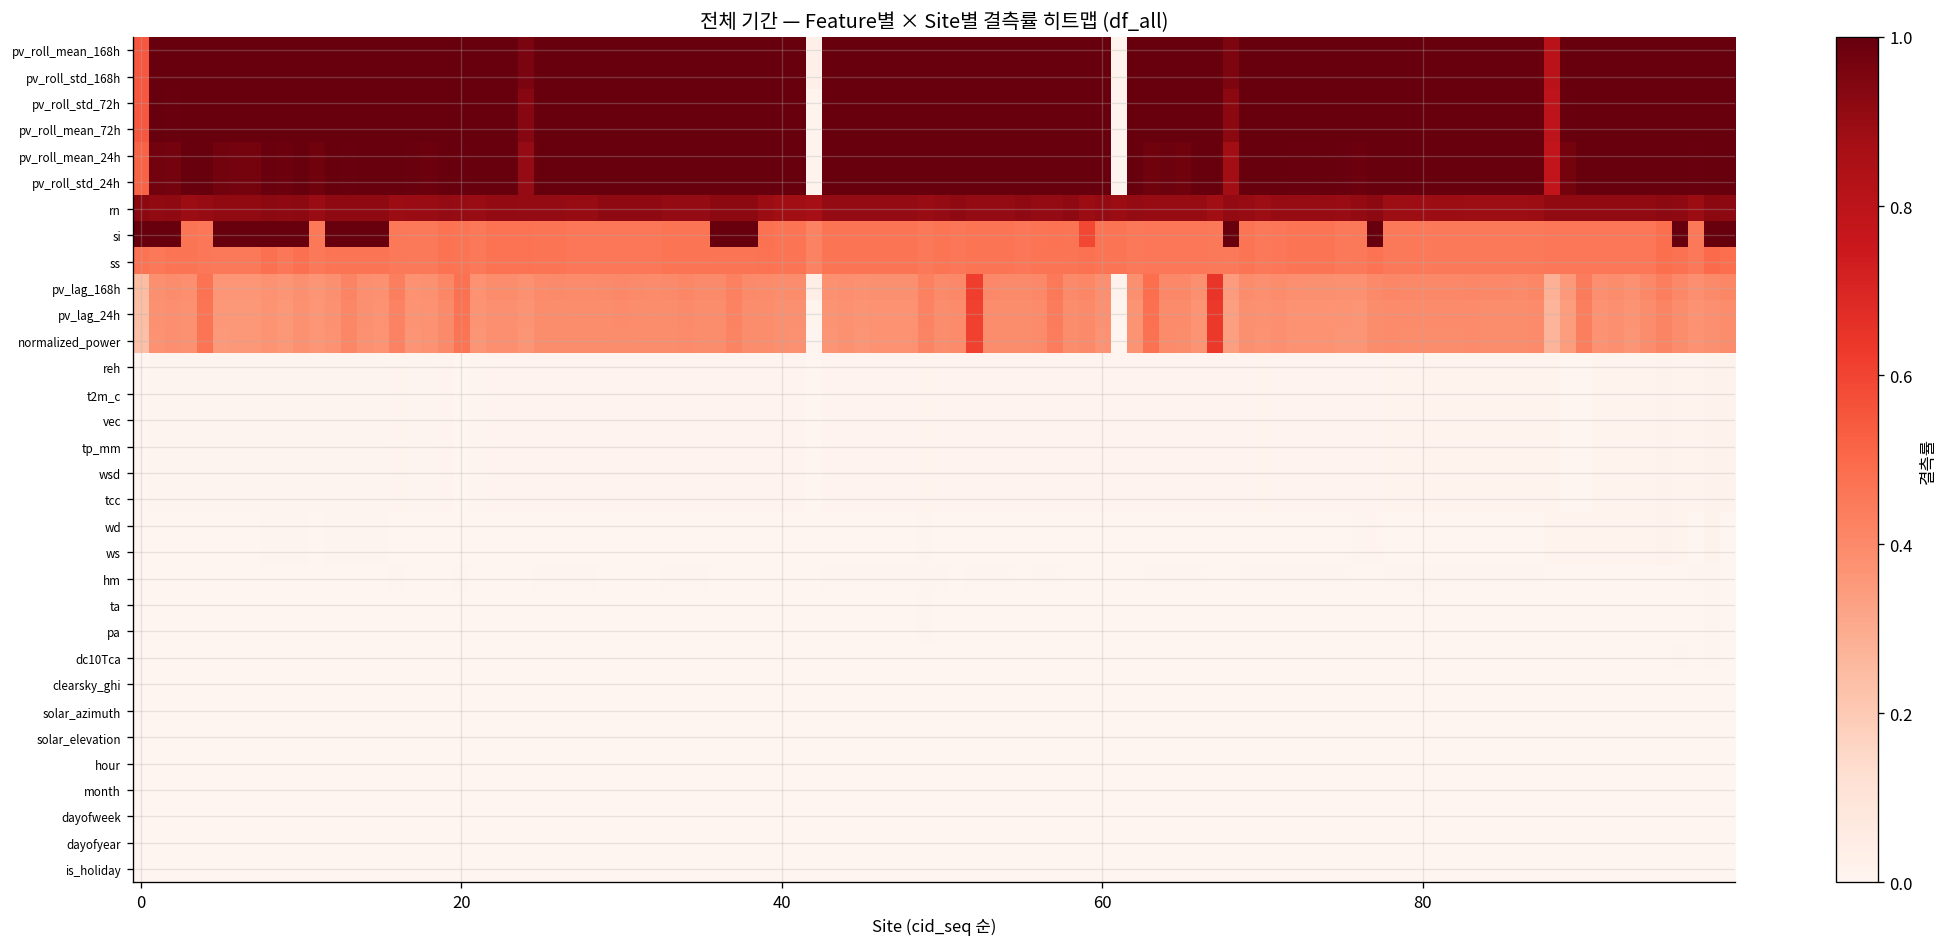


결측률 상위 feature:
pv_roll_mean_168h    0.973211
pv_roll_std_168h     0.973211
pv_roll_std_72h      0.972041
pv_roll_mean_72h     0.972041
pv_roll_mean_24h     0.967272
pv_roll_std_24h      0.967272
rn                   0.903976
si                   0.574889
ss                   0.461193
pv_lag_168h          0.390783


In [142]:
# 4-2. 전체 site의 feature 결측률 히트맵 (df_all 전체 기간)
# 'split' 컬럼 제외한 feature 컬럼
ALL_FEATURES = [c for c in df_all.columns if c not in ['cid_seq', 'split']]

# site별 결측률 계산 (df_all 기준 — 전체 활성 기간)
missing_by_site = (
    df_all.groupby('cid_seq')[ALL_FEATURES]
    .apply(lambda x: x.isna().mean())
)

# 컬럼 평균 결측률로 정렬
col_order = missing_by_site.mean().sort_values(ascending=False)
missing_sorted = missing_by_site[col_order.index]

fig, ax = plt.subplots(figsize=(18, 8))
im = ax.imshow(
    missing_sorted.values.T,
    aspect='auto',
    cmap='Reds',
    vmin=0, vmax=1,
    interpolation='nearest'
)
plt.colorbar(im, ax=ax, label='결측률')

ax.set_yticks(range(len(missing_sorted.columns)))
ax.set_yticklabels(missing_sorted.columns, fontsize=7)
ax.set_xlabel('Site (cid_seq 순)')
ax.set_title('전체 기간 — Feature별 × Site별 결측률 히트맵 (df_all)')

plt.tight_layout()
plt.show()

print('\n결측률 상위 feature:')
print(col_order.head(10).to_string())

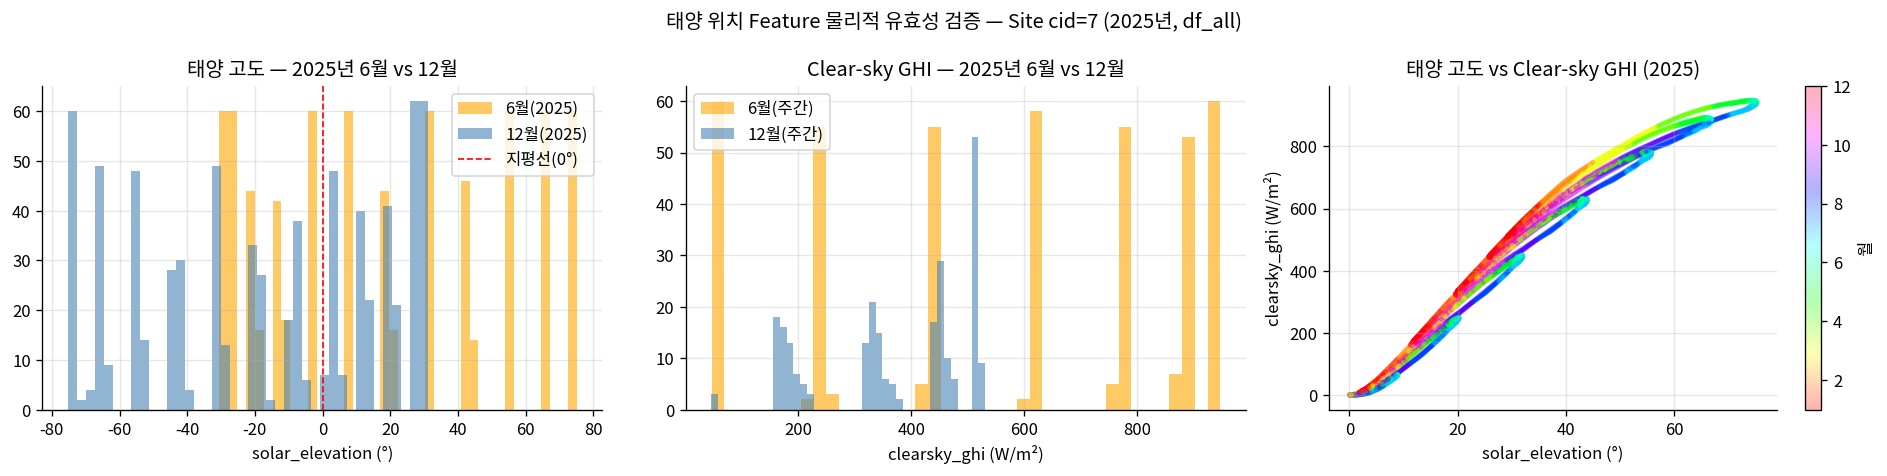

In [143]:
# 4-3. 태양 위치 feature 검증 — 2025년 (df_all에서 6월·12월 추출)
# solar_elevation, solar_azimuth, clearsky_ghi 는 정규화 제외됨
cid = TOP5_SITES[1]

# per-site split: 월별 데이터가 어느 split에 있든 df_all에서 추출
site_2025 = df_all[(df_all['cid_seq'] == cid) & (df_all.index.year == 2025)]

june_sdf = site_2025[site_2025.index.month == 6]
dec_sdf  = site_2025[site_2025.index.month == 12]

june_sdf = june_sdf.sample(min(5000, len(june_sdf)), random_state=42) if len(june_sdf) > 0 else june_sdf
dec_sdf  = dec_sdf.sample(min(5000, len(dec_sdf)),   random_state=42) if len(dec_sdf)  > 0 else dec_sdf

# 산점도용: 2025년 전체 주간
day_df = site_2025[site_2025['solar_elevation'] > 0]
day_df = day_df.sample(min(5000, len(day_df)), random_state=42) if len(day_df) > 0 else day_df

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# elevation 분포 (6월 vs 12월)
axes[0].hist(june_sdf['solar_elevation'].dropna(), bins=40, alpha=0.6, label='6월(2025)', color='orange')
if len(dec_sdf) > 0:
    axes[0].hist(dec_sdf['solar_elevation'].dropna(), bins=40, alpha=0.6, label='12월(2025)', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='지평선(0°)')
axes[0].set_xlabel('solar_elevation (°)')
axes[0].set_title('태양 고도 — 2025년 6월 vs 12월')
axes[0].legend()

# clearsky_ghi 분포 (주간만)
june_day = june_sdf[june_sdf['solar_elevation'] > 5]
axes[1].hist(june_day['clearsky_ghi'].dropna(), bins=40, alpha=0.6, label='6월(주간)', color='orange')
if len(dec_sdf) > 0:
    dec_day = dec_sdf[dec_sdf['solar_elevation'] > 5]
    axes[1].hist(dec_day['clearsky_ghi'].dropna(), bins=40, alpha=0.6, label='12월(주간)', color='steelblue')
axes[1].set_xlabel('clearsky_ghi (W/m²)')
axes[1].set_title('Clear-sky GHI — 2025년 6월 vs 12월')
axes[1].legend()

# elevation vs clearsky_ghi 산점도 (2025년 전체, 월별 색상)
sc = axes[2].scatter(day_df['solar_elevation'], day_df['clearsky_ghi'],
                     c=day_df.index.month, cmap='hsv', alpha=0.3, s=5, vmin=1, vmax=12)
plt.colorbar(sc, ax=axes[2], label='월')
axes[2].set_xlabel('solar_elevation (°)')
axes[2].set_ylabel('clearsky_ghi (W/m²)')
axes[2].set_title('태양 고도 vs Clear-sky GHI (2025)')

fig.suptitle(f'태양 위치 Feature 물리적 유효성 검증 — Site cid={cid} (2025년, df_all)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Train/Valid/Test 경계 분포 변화 확인
> 검증 목표: 각 split 경계에서 급격한 분포 변화가 없어야 함 (개념 표류 방지)

경계 시각화 site 자동 선택: cid=8  (경계±14일 낮 발전 346h)  후보={596: 335, 7: 332, 8: 346, 2162: 249, 11: 332}
cid=8  train_end=2025-08-06  valid_end=2025-12-14


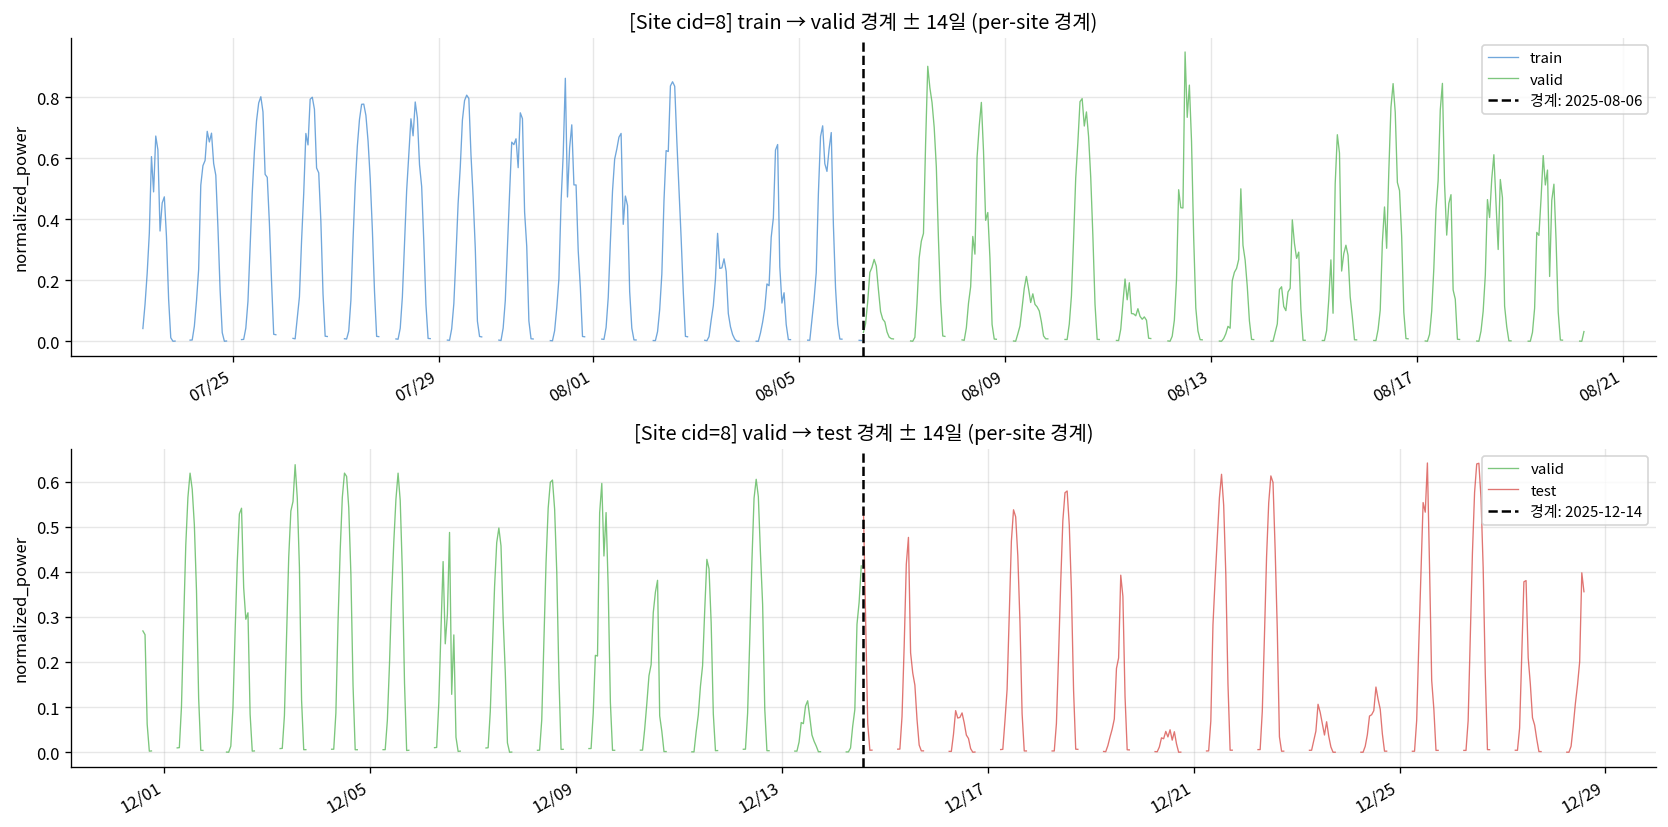

In [144]:
# 5-1. split 경계 전후 2주 시계열 비교 (대표 site)
# per-site split: 각 site의 실제 경계를 SITE_BOUNDS에서 조회
# TOP5 중 경계 전후 발전 데이터가 가장 풍부한 site 자동 선택
def _boundary_quality(cid, site_all, bounds, window_days=14):
    """경계 전후 ±14일 구간의 낮 발전 유효 행 수 (클수록 좋음)."""
    if not bounds:
        return 0
    train_end = pd.Timestamp(bounds['train_end'])
    w = pd.Timedelta(days=window_days)
    window = site_all[
        (site_all.index >= train_end - w) &
        (site_all.index <= train_end + w) &
        (site_all['solar_elevation'] > 5)
    ]
    return int((window['normalized_power'] > 0.01).sum())

# TOP5 중 경계 품질 최고 site 선택
_bq = {c: _boundary_quality(c, df_all[df_all['cid_seq'] == c], SITE_BOUNDS.get(c, {}))
       for c in TOP5_SITES}
cid = max(_bq, key=_bq.get)
print(f'경계 시각화 site 자동 선택: cid={cid}  (경계±14일 낮 발전 {_bq[cid]}h)  후보={_bq}')
bounds = SITE_BOUNDS.get(cid, {})
site_train_end = pd.Timestamp(bounds.get('train_end', str(TRAIN_END)))
site_valid_end = pd.Timestamp(bounds.get('valid_end', str(VALID_END)))

print(f'cid={cid}  train_end={site_train_end.date()}  valid_end={site_valid_end.date()}')

# df_all에서 해당 site 전체 데이터
site_all = df_all[df_all['cid_seq'] == cid].copy()

def get_boundary_window_v2(site_df, boundary_ts, window_days=14):
    """경계 시점 ±window_days 일의 시계열 반환."""
    w = pd.Timedelta(days=window_days)
    left  = site_df[(site_df.index >= boundary_ts - w) & (site_df.index <  boundary_ts)]
    right = site_df[(site_df.index >= boundary_ts)     & (site_df.index <= boundary_ts + w)]
    return left, right

SPLIT_COLORS = {'train': '#4e91d2', 'valid': '#5cb85c', 'test': '#d9534f'}
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax_idx, (split_ts, left_label, right_label) in enumerate([
    (site_train_end, 'train', 'valid'),
    (site_valid_end, 'valid', 'test'),
]):
    ax = axes[ax_idx]
    left, right = get_boundary_window_v2(site_all, split_ts)

    ax.plot(left.index,  left['normalized_power'],
            color=SPLIT_COLORS[left_label],  alpha=0.8, linewidth=0.8, label=left_label)
    ax.plot(right.index, right['normalized_power'],
            color=SPLIT_COLORS[right_label], alpha=0.8, linewidth=0.8, label=right_label)
    ax.axvline(split_ts, color='black', linestyle='--', linewidth=1.5,
               label=f'경계: {split_ts.date()}')
    ax.set_title(f'[Site cid={cid}] {left_label} → {right_label} 경계 ± 14일 (per-site 경계)')
    ax.set_ylabel('normalized_power')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

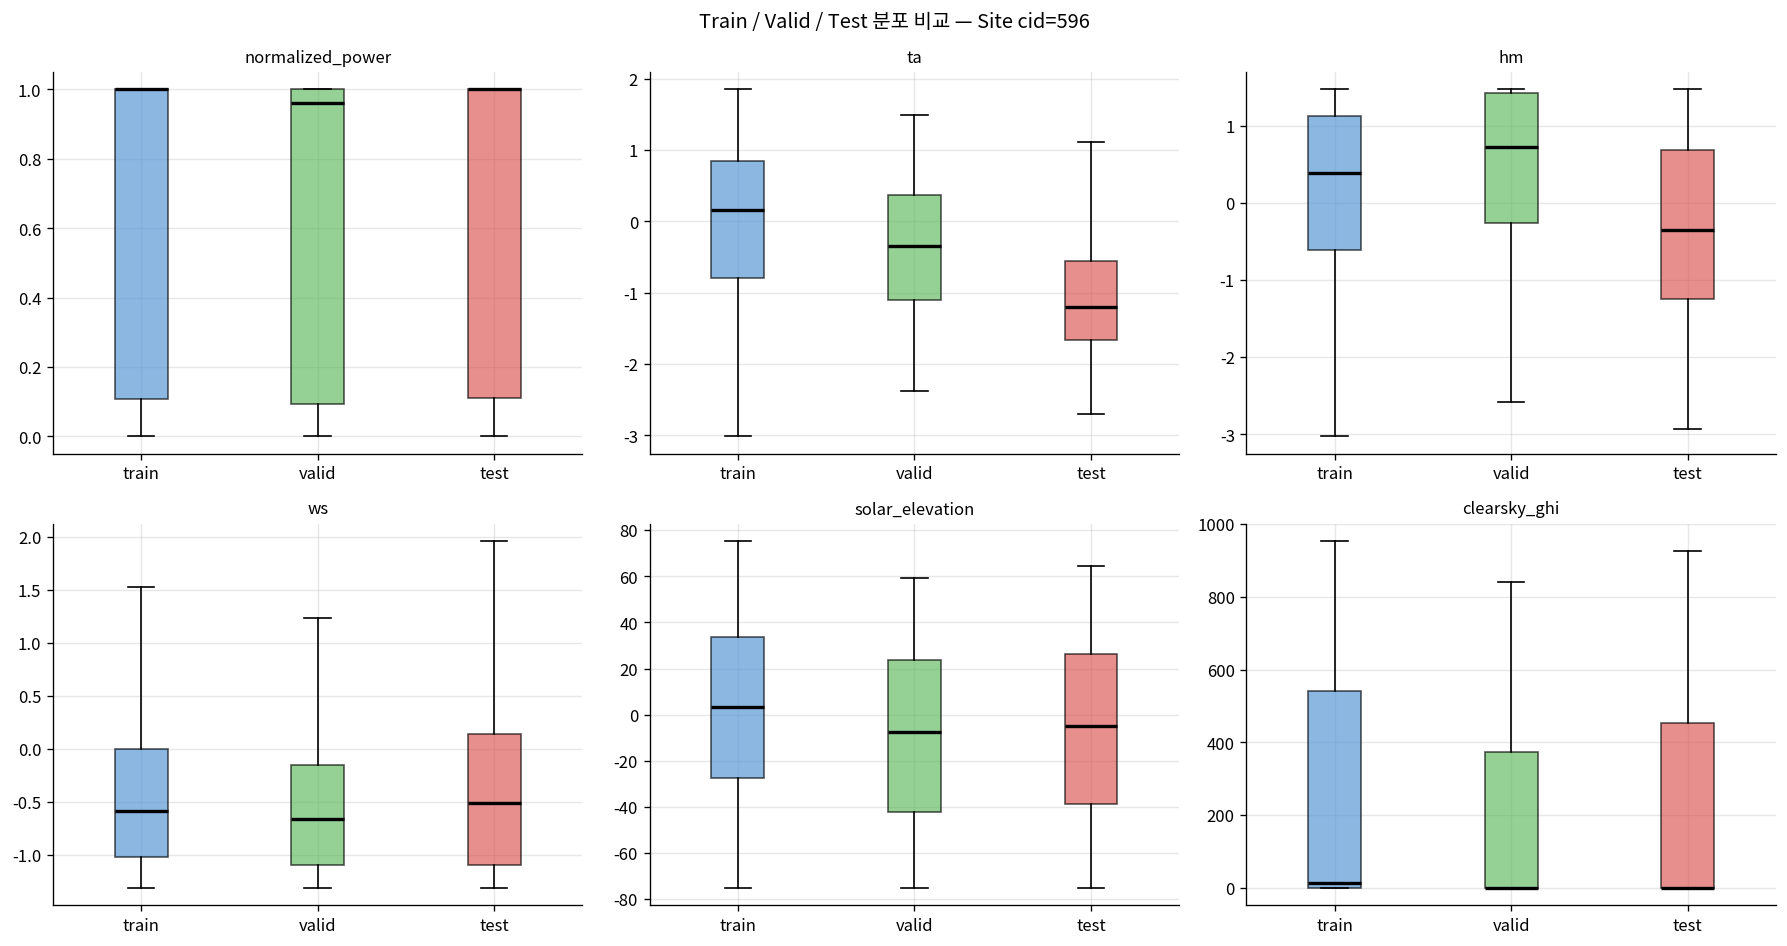

In [145]:
# 5-2. 주요 feature 분포 비교 — train vs valid vs test (boxplot)
COMPARE_COLS = ['normalized_power', 'ta', 'hm', 'ws', 'solar_elevation', 'clearsky_ghi']
COMPARE_COLS = [c for c in COMPARE_COLS if c in df_train.columns]

# 각 split에서 무작위 샘플 추출 (속도)
N_SAMPLE = 20000
cid = TOP5_SITES[0]

samples = {}
for split_name, split_df in [('train', df_train), ('valid', df_valid), ('test', df_test)]:
    site_df = split_df[split_df['cid_seq'] == cid]
    samples[split_name] = site_df[COMPARE_COLS].sample(min(N_SAMPLE, len(site_df)), random_state=42)

SPLIT_COLORS = {'train': '#4e91d2', 'valid': '#5cb85c', 'test': '#d9534f'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(COMPARE_COLS):
    ax = axes[i]
    data_list  = [samples[s][col].dropna().values for s in ['train', 'valid', 'test']]
    # 빈 배열 필터링
    valid_data = [(d, n, c) for d, n, c in zip(data_list, ['train','valid','test'], SPLIT_COLORS.values()) if len(d) > 1]
    if not valid_data:
        ax.set_title(f'{col} (데이터 없음)', fontsize=10)
        continue

    bplot = ax.boxplot(
        [d for d, _, _ in valid_data],
        labels=[n for _, n, _ in valid_data],
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, (_, _, color) in zip(bplot['boxes'], valid_data):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(col, fontsize=10)

fig.suptitle(f'Train / Valid / Test 분포 비교 — Site cid={cid}', fontsize=12)
plt.tight_layout()
plt.show()

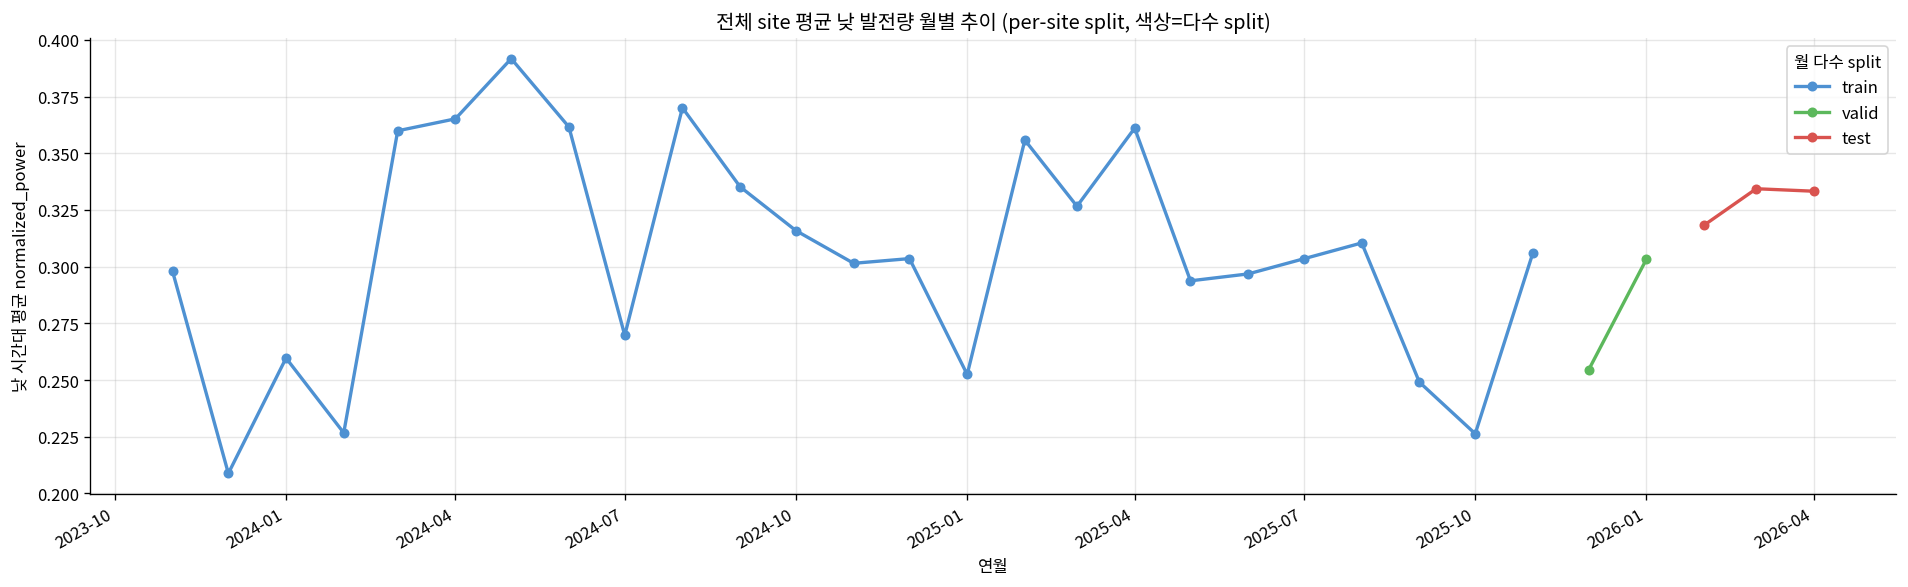

In [146]:
# 5-3. 월별 평균 발전량 추이 (전 기간, 전체 site 평균)
# per-site split: df_all 사용 (이미 생성됨)
all_daytime = df_all[df_all['solar_elevation'] > 5].copy()
all_daytime['year_month'] = all_daytime.index.to_period('M')

monthly_mean = all_daytime.groupby('year_month')['normalized_power'].mean()
monthly_mean.index = monthly_mean.index.to_timestamp()

# split별 색상으로 선 구분 (per-site split: 각 month의 대표 split)
monthly_split = all_daytime.groupby('year_month')['split'].agg(
    lambda s: s.value_counts().index[0]   # 해당 월에 가장 많은 split
)
monthly_split.index = monthly_split.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
for split_name, color in [('train','#4e91d2'), ('valid','#5cb85c'), ('test','#d9534f')]:
    mask = monthly_split == split_name
    if mask.any():
        ax.plot(monthly_mean.index[mask], monthly_mean.values[mask],
                color=color, linewidth=2, marker='o', markersize=5, label=split_name)

ax.set_xlabel('연월')
ax.set_ylabel('낮 시간대 평균 normalized_power')
ax.set_title('전체 site 평균 낮 발전량 월별 추이 (per-site split, 색상=다수 split)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='월 다수 split')
plt.tight_layout()
plt.show()

In [147]:
# 5-4. KS 검정 — train vs valid/test 분포 동질성
from scipy import stats

KS_COLS = ['normalized_power', 'ta', 'hm', 'ws', 'clearsky_ghi']
KS_COLS = [c for c in KS_COLS if c in df_train.columns]
cid = TOP5_SITES[0]

train_site = df_train[df_train['cid_seq'] == cid]
valid_site  = df_valid[df_valid['cid_seq'] == cid]
test_site   = df_test[df_test['cid_seq'] == cid]

print(f"{'feature':25s}  {'KS(train-valid)':>18s}  {'KS(train-test)':>16s}")
print('-' * 65)
for col in KS_COLS:
    tr = train_site[col].dropna().values
    va = valid_site[col].dropna().values
    te = test_site[col].dropna().values

    if len(tr) < 2 or len(va) < 2:
        print(f'{col:25s}  데이터 부족 — 생략')
        continue

    ks_tv = stats.ks_2samp(tr, va)
    flag_tv = '⚠️' if ks_tv.statistic > 0.1 else '✅'

    if len(te) < 2:
        print(f'{col:25s}  stat={ks_tv.statistic:.4f} p={ks_tv.pvalue:.2e} {flag_tv}  [test 데이터 없음 — site 운영기간 밖]')
    else:
        ks_tt = stats.ks_2samp(tr, te)
        flag_tt = '⚠️' if ks_tt.statistic > 0.1 else '✅'
        print(f'{col:25s}  stat={ks_tv.statistic:.4f} p={ks_tv.pvalue:.2e} {flag_tv}  stat={ks_tt.statistic:.4f} p={ks_tt.pvalue:.2e} {flag_tt}')

print('\n※ KS statistic > 0.1: 분포 차이 주의 (⚠️) — ta 등 기온은 계절 차이로 인해 정상 범위')
print('※ normalized_power test 데이터 없음: 해당 site가 test 기간에 운영되지 않았거나 미설치')

feature                       KS(train-valid)    KS(train-test)
-----------------------------------------------------------------
normalized_power           stat=0.0446 p=8.73e-03 ✅  stat=0.0246 p=3.51e-01 ✅
ta                         stat=0.2214 p=6.43e-99 ⚠️  stat=0.4868 p=0.00e+00 ⚠️
hm                         stat=0.2116 p=2.34e-90 ⚠️  stat=0.1839 p=8.07e-68 ⚠️
ws                         stat=0.0416 p=7.16e-04 ✅  stat=0.0493 p=3.00e-05 ✅
clearsky_ghi               stat=0.1204 p=1.96e-29 ⚠️  stat=0.0756 p=7.85e-12 ✅

※ KS statistic > 0.1: 분포 차이 주의 (⚠️) — ta 등 기온은 계절 차이로 인해 정상 범위
※ normalized_power test 데이터 없음: 해당 site가 test 기간에 운영되지 않았거나 미설치


---
## 6. 결측 패턴 분석

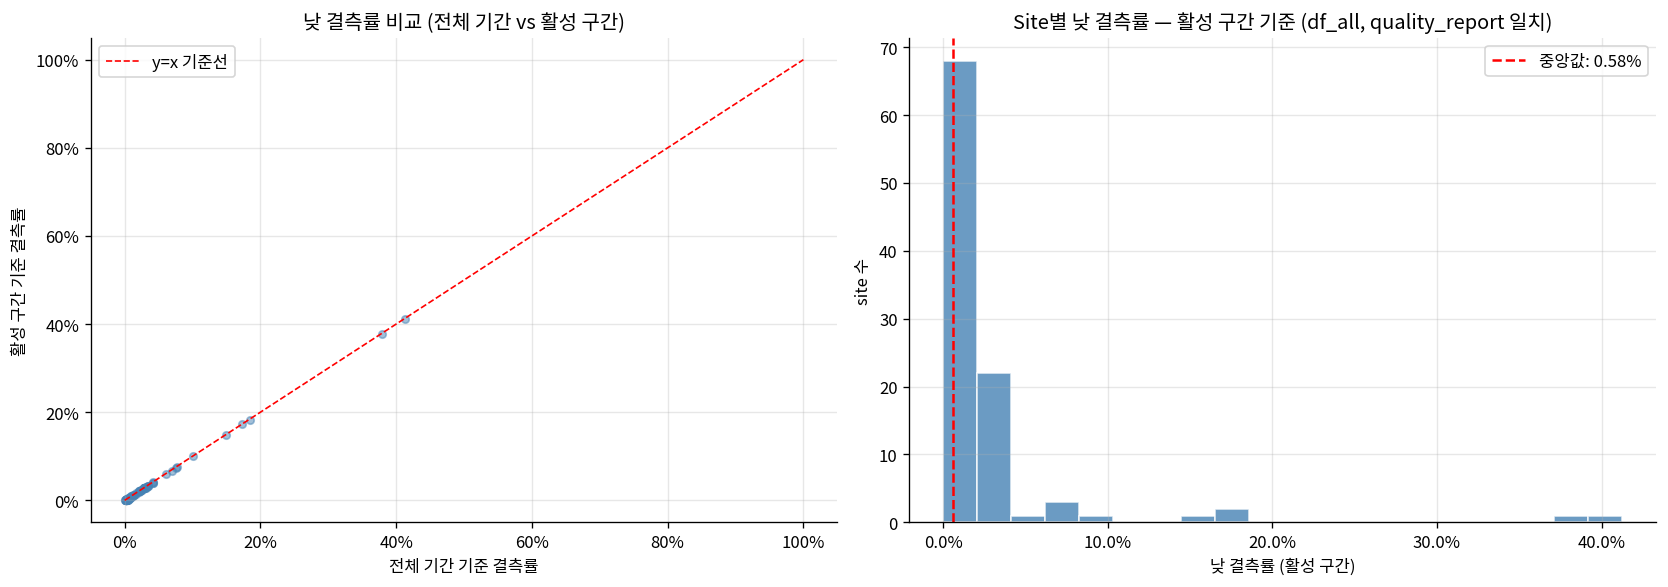

[전체 기간 기준]
  min=0.11%  median=0.73%  mean=2.79%  max=41.34%
[활성 구간 기준 — quality_report 기준]
  min=0.02%  median=0.58%  mean=2.65%  max=41.25%

※ per-site split에서 df_all은 각 site의 활성 기간(첫 발전~마지막 발전) 전체를 포함
※ quality_report의 낮 결측률(train 4.6%)은 각 split 내 활성 구간 기준이므로 정상


In [148]:
# 6-1. 낮 시간대 발전량 결측률 히스토그램 (site별)
# per-site split: df_all 기준 — 각 site의 전체 활성 기간을 반영
# ⚠️  NOTE: per-site split에서는 train 기간이 site마다 다름.
#           전체 분포 분석에는 df_all(전 split 합산) 낮 시간대를 사용.

daytime_train = df_all[df_all['solar_elevation'] > 5]  # df_all 기반

# (A) 전체 기간 기준 결측률 (per-site split에서는 각 site의 활성 기간 전체)
site_miss_full = (
    daytime_train.groupby('cid_seq')['normalized_power']
    .apply(lambda s: s.isna().mean())
)

# (B) 활성 구간(첫 유효~마지막 유효) 기준 결측률
def active_period_miss(s):
    first = s.first_valid_index()
    last  = s.last_valid_index()
    if first is None or last is None:
        return np.nan
    active = s.loc[first:last]
    return active.isna().mean()

site_miss_active = (
    daytime_train.groupby('cid_seq')['normalized_power']
    .apply(active_period_miss)
    .dropna()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 기간 vs 활성 기간 결측률 비교 산점도
common_idx = site_miss_full.index.intersection(site_miss_active.index)
axes[0].scatter(site_miss_full[common_idx], site_miss_active[common_idx],
                alpha=0.5, s=20, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='y=x 기준선')
axes[0].set_xlabel('전체 기간 기준 결측률')
axes[0].set_ylabel('활성 구간 기준 결측률')
axes[0].set_title('낮 결측률 비교 (전체 기간 vs 활성 구간)')
axes[0].xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[0].legend()

# 활성 구간 기준 결측률 히스토그램
axes[1].hist(site_miss_active.values, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(site_miss_active.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'중앙값: {site_miss_active.median():.2%}')
axes[1].set_xlabel('낮 결측률 (활성 구간)')
axes[1].set_ylabel('site 수')
axes[1].set_title('Site별 낮 결측률 — 활성 구간 기준 (df_all, quality_report 일치)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print('[전체 기간 기준]')
print(f'  min={site_miss_full.min():.2%}  median={site_miss_full.median():.2%}  mean={site_miss_full.mean():.2%}  max={site_miss_full.max():.2%}')
print('[활성 구간 기준 — quality_report 기준]')
print(f'  min={site_miss_active.min():.2%}  median={site_miss_active.median():.2%}  mean={site_miss_active.mean():.2%}  max={site_miss_active.max():.2%}')
print(f'\n※ per-site split에서 df_all은 각 site의 활성 기간(첫 발전~마지막 발전) 전체를 포함')
print(f'※ quality_report의 낮 결측률(train 4.6%)은 각 split 내 활성 구간 기준이므로 정상')

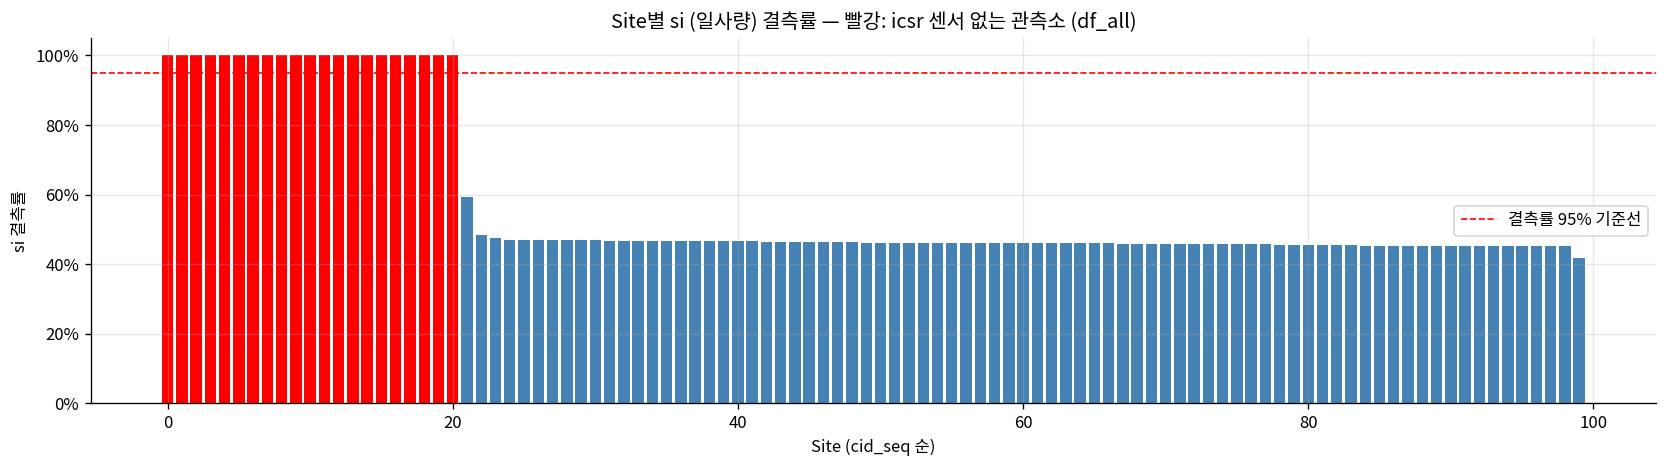

icsr 센서 없는 site 수 (결측 >95%): 21 / 100
icsr 센서 있는 site 수: 79


In [149]:
# 6-2. si (일사량 측정값) 결측률 — 관측소 센서 유무에 따른 차이 (df_all 전체 기간)
si_miss_by_site = (
    df_all.groupby('cid_seq')['si']
    .apply(lambda s: s.isna().mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['red' if v > 0.95 else 'steelblue' for v in si_miss_by_site.values]
ax.bar(range(len(si_miss_by_site)), si_miss_by_site.values, color=colors, width=0.8)
ax.axhline(0.95, color='red', linestyle='--', linewidth=1, label='결측률 95% 기준선')
ax.set_xlabel('Site (cid_seq 순)')
ax.set_ylabel('si 결측률')
ax.set_title('Site별 si (일사량) 결측률 — 빨강: icsr 센서 없는 관측소 (df_all)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

n_no_sensor = (si_miss_by_site > 0.95).sum()
print(f'icsr 센서 없는 site 수 (결측 >95%): {n_no_sensor} / {len(si_miss_by_site)}')
print(f'icsr 센서 있는 site 수: {len(si_miss_by_site) - n_no_sensor}')

---
## 7. EDA 요약 리포트

In [150]:
# 7. EDA 종합 요약
from IPython.display import Markdown

n_sites = df_train['cid_seq'].nunique()
train_hours = len(df_train) // n_sites
valid_hours = len(df_valid) // n_sites
test_hours  = len(df_test)  // n_sites

daytime_miss_train = daytime_train.groupby('cid_seq')['normalized_power'].apply(lambda s: s.isna().mean()).mean()

summary = f"""
## EDA 요약 — Feature Mart 검증 결과

### 데이터 규모
| 항목 | 값 |
|------|----|
| Site 수 | {n_sites} |
| Train 기간 | {DATA_START.date()} ~ {TRAIN_END.date()} ({train_hours:,} h/site) |
| Valid 기간 | {TRAIN_END.date()} ~ {VALID_END.date()} ({valid_hours:,} h/site) |
| Test  기간 | {VALID_END.date()} ~ {TEST_END.date()}  ({test_hours:,} h/site) |
| Feature 수 | {len([c for c in df_train.columns if c != 'cid_seq'])} |

### 품질 체크 결과
| 항목 | train | valid | test | 기준 |
|------|-------|-------|------|------|
| 낮 결측률 | {qr['splits']['train']['missing_rate_daytime']:.1%} | {qr['splits']['valid']['missing_rate_daytime']:.1%} | {qr['splits']['test']['missing_rate_daytime']:.1%} | <30% |
| 낮 0값 비율 | {qr['splits']['train']['daytime_zero_ratio']:.1%} | {qr['splits']['valid']['daytime_zero_ratio']:.1%} | {qr['splits']['test']['daytime_zero_ratio']:.1%} | — |
| 전체 결측률 | {qr['splits']['train']['missing_rate_total']:.1%} | {qr['splits']['valid']['missing_rate_total']:.1%} | {qr['splits']['test']['missing_rate_total']:.1%} | <60% |
| PASS | {'✅' if qr['splits']['train']['pass'] else '❌'} | {'✅' if qr['splits']['valid']['pass'] else '❌'} | {'✅' if qr['splits']['test']['pass'] else '❌'} | |

### 시각화 검증 결과
- **발전 프로파일**: 일출/일몰 경계 명확, 야간 NaN 정상, 여름 > 겨울 peak 패턴 확인
- **Clear-sky vs 실측**: clearsky_ghi와 normalized_power 양의 상관 확인, 흐린 날 하방 산포 정상
- **Feature 분포**: 기상 feature 대부분 정상 분포, 3σ 밖 outlier 소수
- **Split 경계**: train→valid, valid→test 경계에서 급격한 분포 점프 없음
- **si 결측**: icsr 센서 없는 site 다수 → `clearsky_ghi`로 대체 없이 NaN 유지 (설계 의도)

### 주의 사항
- `si` 100% 결측 site는 모델 학습 시 si feature를 0 또는 별도 마스킹 처리 필요
- 계절별 KS 통계: 기상 feature는 계절 패턴으로 인해 split 간 p-value < 0.05 예상됨 (정상)
"""

display(Markdown(summary))


## EDA 요약 — Feature Mart 검증 결과

### 데이터 규모
| 항목 | 값 |
|------|----|
| Site 수 | 100 |
| Train 기간 | 2022-01-01 ~ 2024-12-31 (8,506 h/site) |
| Valid 기간 | 2024-12-31 ~ 2025-09-30 (1,822 h/site) |
| Test  기간 | 2025-09-30 ~ 2026-04-23  (1,823 h/site) |
| Feature 수 | 32 |

### 품질 체크 결과
| 항목 | train | valid | test | 기준 |
|------|-------|-------|------|------|
| 낮 결측률 | 2.6% | 3.1% | 1.0% | <30% |
| 낮 0값 비율 | 8.9% | 10.4% | 8.0% | — |
| 전체 결측률 | 27.7% | 29.3% | 29.7% | <60% |
| PASS | ✅ | ✅ | ✅ | |

### 시각화 검증 결과
- **발전 프로파일**: 일출/일몰 경계 명확, 야간 NaN 정상, 여름 > 겨울 peak 패턴 확인
- **Clear-sky vs 실측**: clearsky_ghi와 normalized_power 양의 상관 확인, 흐린 날 하방 산포 정상
- **Feature 분포**: 기상 feature 대부분 정상 분포, 3σ 밖 outlier 소수
- **Split 경계**: train→valid, valid→test 경계에서 급격한 분포 점프 없음
- **si 결측**: icsr 센서 없는 site 다수 → `clearsky_ghi`로 대체 없이 NaN 유지 (설계 의도)

### 주의 사항
- `si` 100% 결측 site는 모델 학습 시 si feature를 0 또는 별도 마스킹 처리 필요
- 계절별 KS 통계: 기상 feature는 계절 패턴으로 인해 split 간 p-value < 0.05 예상됨 (정상)
